# LoRA Baseline — Training and Evaluation

This notebook trains and evaluates the **LoRA parameter-efficient fine-tuning baseline** used in the thesis.

The frozen backbone is `meta-llama/Llama-3.1-8B-Instruct`, augmented with LoRA adapters applied to the attention and MLP projection layers.

Training uses the **Balanced CEFR Steering Subset**, containing 5,568 examples with equal representation across the six CEFR levels (A1–C2). A stratified 90/10 train-validation split is applied with `random_state=42`.

The notebook includes:

- LoRA adapter configuration and training;
- validation-loss and perplexity tracking;
- hardware profiling;
- publication of the trained adapter to Hugging Face;
- generation on the final In-Domain Evaluation Prompt Matrix;
- evaluation with the primary Joint-Loss CEFR evaluator;
- CEFR-control and linguistic diagnostic metrics.

The trained LoRA adapter is evaluated on the same 702-condition in-domain benchmark used for the other control methods in the thesis.

In [ ]:
# =========================================================
# 0. ENVIRONMENT SETUP & DEPENDENCIES
# =========================================================
!pip install -q transformers peft torch datasets huggingface_hub accelerate scikit-learn hf_transfer tqdm nvidia-ml-py "torchao>=0.16.0"

import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

import gc
import json
import time
import math
import threading
import pynvml
import torch
import pandas as pd
import numpy as np
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    get_cosine_schedule_with_warmup
)
from peft import LoraConfig, get_peft_model, TaskType
from huggingface_hub import login, HfApi
from google.colab import drive, userdata
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 76.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 120.5 MB/s eta 0:00:00


/usr/local/lib/python3.13/dist-packages/huggingface_hub/constants.py:299: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

# Configuration Paths - Updated for 6k dataset
DATASET_CSV_PATH = "/content/drive/MyDrive/Your_Path/balanced_cefr_steering_subset.csv"
DRIVE_LOG_DIR = "/content/drive/MyDrive/Your_Path/lora_training_logs"
HF_REPO_ID = "MohammadKhosravi/llama3.1-8b-lora-cefr-steering-6k"
LOCAL_OUTPUT_DIR = "./lora_cefr_export_6k"

os.makedirs(DRIVE_LOG_DIR, exist_ok=True)
os.makedirs(LOCAL_OUTPUT_DIR, exist_ok=True)

# Authentication
try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
except Exception:
    pass

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using execution device: {device}")
if torch.cuda.is_available():
    print(f"Device Name: {torch.cuda.get_device_name(0)}")

Mounted at /content/drive
Using execution device: cuda
Device Name: NVIDIA A100-SXM4-80GB


In [ ]:
# =========================================================
# 1. INGEST BALANCED DATASET & STRATIFIED SPLIT (90/10)
# =========================================================
print(f"\n📥 Ingesting Steering Training Dataset from: {DATASET_CSV_PATH}")
df = pd.read_csv(DATASET_CSV_PATH).dropna(subset=['cefr', 'clean_text', 'topic_title'])
df['cefr'] = df['cefr'].str.upper().str.strip()

label_map = {"A1": 0, "A2": 1, "B1": 2, "B2": 3, "C1": 4, "C2": 5}
df['cefr_id'] = df['cefr'].map(label_map)
df = df.dropna(subset=['cefr_id'])
df['cefr_id'] = df['cefr_id'].astype(int)

# Stratified 90/10 Split
train_df, val_df = train_test_split(
    df,
    test_size=0.10,
    stratify=df['cefr_id'],
    random_state=42
)

print(f"Training partition size:   {len(train_df):,} samples")
print(f"Validation partition size: {len(val_df):,} samples")


📥 Ingesting Steering Training Dataset from: /content/drive/MyDrive/Mohammd_Thesis/subsets/efcamdat_balanced_subset_training.csv
Training partition size:   5,011 samples
Validation partition size: 557 samples


In [ ]:
# =========================================================
# 2. LOAD BASE LLM & CONFIGURE PEFT LORA
# =========================================================
model_id = "meta-llama/Llama-3.1-8B-Instruct"
print(f"\nLoading tokenizer and base model: {model_id}...")

# Right padding is optimal for training Causal LMs
tokenizer = AutoTokenizer.from_pretrained(model_id)
tokenizer.padding_side = "right"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map={"": torch.cuda.current_device()}
)

# Enable gradient checkpointing to save VRAM on long sequences
base_model.gradient_checkpointing_enable()
base_model.config.use_cache = False  # Disable KV Cache for checkpointing compatibility

# LoRA Configuration
peft_config = LoraConfig(
    task_type=TaskType.CAUSAL_LM,
    r=16,
    lora_alpha=32,
    lora_dropout=0.05,
    bias="none",
    target_modules=[
        "q_proj", "k_proj", "v_proj", "o_proj",
        "gate_proj", "up_proj", "down_proj"
    ]
)

model = get_peft_model(base_model, peft_config)
model.print_trainable_parameters()


Loading tokenizer and base model: meta-llama/Llama-3.1-8B-Instruct...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

trainable params: 41,943,040 || all params: 8,072,204,288 || trainable%: 0.5196


In [ ]:
# =========================================================
# 3. DATASET UTILITY WITH RIGOROUS PROMPT MASKING
# =========================================================
class CEFRTopicDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=512):
        self.data = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        t_cefr = row['cefr']
        topic_title = str(row['topic_title']).strip()

        # Exact standardized prompt format from thesis infrastructure
        prompt = (
            f"You are an expert English language teacher demonstrating CEFR proficiency levels. "
            f"Your task is to write a flawless, grammatically correct text responding to this prompt: '{topic_title}'. "
            f"The output must serve as a perfect textbook example of strictly {t_cefr} level English. "
            f"If the requested target level is A1/A2, use very simple vocabulary, short sentences, and primitive structures. "
            f"If the requested target level is C1/C2, utilize highly advanced vocabulary, idioms, and complex sentence patterns. "
            f"Write only the direct response. Do not write any meta-commentary, greetings, or conversational pleasantries."
        )

        messages = [{"role": "user", "content": prompt}]
        formatted_prompt = self.tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
        full_text = formatted_prompt + str(row['clean_text']).strip() + self.tokenizer.eos_token

        # Tokenize only the prompt to find its exact token length
        prompt_enc = self.tokenizer(
            formatted_prompt,
            add_special_tokens=False,
            truncation=True,
            max_length=self.max_length
        )
        prompt_len = len(prompt_enc['input_ids'])

        # Tokenize the entire sequence with matching special token config
        full_enc = self.tokenizer(
            full_text,
            add_special_tokens=False,
            truncation=True,
            max_length=self.max_length,
            padding='max_length'
        )

        input_ids = torch.tensor(full_enc['input_ids'], dtype=torch.long)
        attention_mask = torch.tensor(full_enc['attention_mask'], dtype=torch.long)

        # Clone inputs for labels, then strictly mask out non-target tokens
        labels = input_ids.clone()
        labels[:prompt_len] = -100                 # Mask prompt tokens
        labels[attention_mask == 0] = -100         # Mask padding tokens

        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels
        }

# Batch sizes configured for NVIDIA A100 40GB
TRAIN_BATCH_SIZE = 32
GRADIENT_ACCUMULATION_STEPS = 2   # Effective batch size = 64
VAL_BATCH_SIZE = 32

train_loader = DataLoader(
    CEFRTopicDataset(train_df, tokenizer),
    batch_size=TRAIN_BATCH_SIZE,
    shuffle=True,
    pin_memory=True
)
val_loader = DataLoader(
    CEFRTopicDataset(val_df, tokenizer),
    batch_size=VAL_BATCH_SIZE,
    shuffle=False,
    pin_memory=True
)

In [ ]:
# =========================================================
# 4. HARDWARE PROFILER (BACKGROUND NVML DAEMON)
# =========================================================
class GPUMonitor(threading.Thread):
    def __init__(self, delay=1.0):
        super(GPUMonitor, self).__init__()
        self.stopped = False
        self.delay = delay
        self.utilization_rates = []
        pynvml.nvmlInit()
        self.handle = pynvml.nvmlDeviceGetHandleByIndex(0)

    def run(self):
        while not self.stopped:
            try:
                util = pynvml.nvmlDeviceGetUtilizationRates(self.handle)
                self.utilization_rates.append(util.gpu)
            except Exception:
                pass
            time.sleep(self.delay)

    def stop(self):
        self.stopped = True
        try:
            pynvml.nvmlShutdown()
        except Exception:
            pass

    def get_avg_utilization(self):
        if not self.utilization_rates: return 0.0
        return sum(self.utilization_rates) / len(self.utilization_rates)

In [ ]:
# =========================================================
# 5. OPTIMIZATION & TRAINING LOOP (WITH PROFILING)
# =========================================================
epochs = 3
lr = 2e-4
optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)

# Corrected training steps calculation using math.ceil
total_training_steps = math.ceil(len(train_loader) / GRADIENT_ACCUMULATION_STEPS) * epochs
warmup_steps = int(0.05 * total_training_steps)

scheduler = get_cosine_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_training_steps
)

best_val_loss = float('inf')
best_model_path = os.path.join(LOCAL_OUTPUT_DIR, "best_lora_weights")
training_summary_logs = []

print(f"\n🚀 Launching LoRA Fine-Tuning across {epochs} Epochs...")
print(f"Total optimization steps: {total_training_steps:,} | Warmup steps: {warmup_steps}")

# ----------------- START PROFILER -----------------
torch.cuda.reset_peak_memory_stats()
gpu_monitor = GPUMonitor(delay=1.0)
gpu_monitor.start()
start_time = time.perf_counter()
# --------------------------------------------------

for epoch in range(epochs):
    model.train()
    running_train_loss = 0.0
    optimizer.zero_grad()

    progress_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
    for step, batch in enumerate(progress_bar):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        # Forward pass: HF automatically handles causal shifting and excludes -100 tokens from the loss
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        # Scale loss for gradient accumulation
        loss = loss / GRADIENT_ACCUMULATION_STEPS
        loss.backward()

        running_train_loss += loss.item() * GRADIENT_ACCUMULATION_STEPS

        if (step + 1) % GRADIENT_ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        progress_bar.set_postfix({"Loss": f"{loss.item() * GRADIENT_ACCUMULATION_STEPS:.4f}"})

    # Validation Loop
    model.eval()
    val_loss_accum = 0.0
    val_steps = 0

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

            val_loss_accum += outputs.loss.item()
            val_steps += 1

    avg_train_loss = running_train_loss / len(train_loader)
    avg_val_loss = val_loss_accum / val_steps
    val_ppl = float(np.exp(avg_val_loss))

    epoch_metrics = {
        "epoch": epoch + 1,
        "train_loss": round(avg_train_loss, 4),
        "val_loss": round(avg_val_loss, 4),
        "val_ppl": round(val_ppl, 2)
    }
    training_summary_logs.append(epoch_metrics)

    print(f"\n📈 [Epoch {epoch+1}/{epochs}] Done | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val PPL: {val_ppl:.2f}")

    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        # Automatically saves only the LoRA adapter parameters
        model.save_pretrained(best_model_path)
        tokenizer.save_pretrained(best_model_path)
        print(f"🌟 Best validation score achieved! Saved checkpoint to {best_model_path}")

    # Synchronize and free VRAM
    torch.cuda.empty_cache()
    gc.collect()

# ----------------- STOP PROFILER -----------------
gpu_monitor.stop()
end_time = time.perf_counter()
# -------------------------------------------------

# Save Training Summary
json_log_path = os.path.join(DRIVE_LOG_DIR, "lora_training_summary_6k.json")
with open(json_log_path, "w") as f:
    json.dump(training_summary_logs, f, indent=4)
with open(os.path.join(LOCAL_OUTPUT_DIR, "training_summary_6k.json"), "w") as f:
    json.dump(training_summary_logs, f, indent=4)


🚀 Launching LoRA Fine-Tuning across 3 Epochs...
Total optimization steps: 237 | Warmup steps: 11


Epoch 1/3 [Train]:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 1/3 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]


📈 [Epoch 1/3] Done | Train Loss: 2.5610 | Val Loss: 2.4400 | Val PPL: 11.47
🌟 Best validation score achieved! Saved checkpoint to ./lora_cefr_export_6k/best_lora_weights


Epoch 2/3 [Train]:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 2/3 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]


📈 [Epoch 2/3] Done | Train Loss: 2.2555 | Val Loss: 2.3686 | Val PPL: 10.68
🌟 Best validation score achieved! Saved checkpoint to ./lora_cefr_export_6k/best_lora_weights


Epoch 3/3 [Train]:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch 3/3 [Val]:   0%|          | 0/18 [00:00<?, ?it/s]


📈 [Epoch 3/3] Done | Train Loss: 2.0510 | Val Loss: 2.3943 | Val PPL: 10.96


In [ ]:
# =========================================================
# 6. EXPORT PROFILING REPORT TO TXT
# =========================================================
total_time_seconds = end_time - start_time
total_time_hours = total_time_seconds / 3600
avg_gpu_util = gpu_monitor.get_avg_utilization()
peak_vram_gb = torch.cuda.max_memory_allocated() / (1024**3)

profiling_report = (
    "=== LoRA Hardware Profiling Report (6k Balanced Dataset) ===\n"
    f"Total training time: {total_time_seconds:.2f} seconds ({total_time_hours:.2f} hours)\n"
    f"Peak GPU memory: {peak_vram_gb:.2f} GB\n"
    f"Average GPU utilization: {avg_gpu_util:.1f}%\n"
)
print("\n" + profiling_report)

profiling_txt_path = os.path.join(DRIVE_LOG_DIR, "lora_hardware_profiling_6k.txt")
with open(profiling_txt_path, "w") as f:
    f.write(profiling_report)
with open(os.path.join(LOCAL_OUTPUT_DIR, "lora_hardware_profiling_6k.txt"), "w") as f:
    f.write(profiling_report)

print(f"📊 Training logs and hardware profiling successfully recorded in Google Drive.")



=== LoRA Hardware Profiling Report (6k Balanced Dataset) ===
Total training time: 3044.87 seconds (0.85 hours)
Peak GPU memory: 47.26 GB
Average GPU utilization: 98.6%

📊 Training logs and hardware profiling successfully recorded in Google Drive.


In [ ]:
# =========================================================
# 7. EXPORT CHECKPOINTS & PUSH TO HUGGING FACE HUB
# =========================================================

print("\n📦 Packaging and uploading model adapter to Hugging Face...")

# ---------------------------------------------------------
# Construct README
# ---------------------------------------------------------

readme_content = f"""---
license: apache-2.0
base_model: {model_id}
tags:
- peft
- lora
- cefr-steering
- language-proficiency
- text-generation
---

# Llama-3.1-8B-Instruct LoRA Baseline (6k Balanced Steering Dataset)

This repository contains the PEFT LoRA adapter weights trained on a
6k balanced subset of the EFCAMDAT Steering Dataset for explicit
CEFR-aligned text generation.

## Training Configuration

- **Backbone**: `meta-llama/Llama-3.1-8B-Instruct`
- **LoRA Parameters**: $r=16$, $\\alpha=32$, dropout $=0.05$
- **Target Modules**: All linear attention and MLP projections
  (`q_proj`, `k_proj`, `v_proj`, `o_proj`, `gate_proj`, `up_proj`, `down_proj`)
- **Loss Strategy**: Standard Causal Language Modeling Loss (Cross-Entropy).
  Padding and prompt tokens rigorously masked (`-100`).
- **Dataset Size**: ~6,000 balanced samples (Stratified 90% Train / 10% Validation)
- **Batch Size**: 16 (effective 32 via gradient accumulation)
- **Hardware**: 1x NVIDIA A100 40GB

## Training Progression Logs

{json.dumps(training_summary_logs, indent=2)}

## Hardware Profiling

- **Total training time**: {total_time_seconds:.2f} seconds ({total_time_hours:.2f} hours)
- **Peak GPU memory**: {peak_vram_gb:.2f} GB
- **Average GPU utilization**: {avg_gpu_util:.1f}%
"""

# ---------------------------------------------------------
# Save README
# ---------------------------------------------------------

readme_path = os.path.join(best_model_path, "README.md")

with open(readme_path, "w", encoding="utf-8") as f:
    f.write(readme_content)

print(f"✅ README saved to: {readme_path}")

# ---------------------------------------------------------
# Push model adapter to Hugging Face Hub
# ---------------------------------------------------------

try:
    api = HfApi()

    # Create repository if it does not already exist
    api.create_repo(
        repo_id=HF_REPO_ID,
        repo_type="model",
        exist_ok=True
    )

    # Upload LoRA adapter weights, tokenizer, config, and README
    api.upload_folder(
        folder_path=best_model_path,
        repo_id=HF_REPO_ID,
        repo_type="model",
        commit_message=(
            f"Upload CEFR LoRA fine-tuning adapter "
            f"(Val PPL: {np.exp(best_val_loss):.2f})"
        )
    )

    print(
        f"🚀 SUCCESS! LoRA adapter weights pushed to:\n"
        f"https://huggingface.co/{HF_REPO_ID}"
    )

except Exception as e:
    print(f"⚠️ Hugging Face upload failed: {str(e)}")


📦 Packaging and uploading model adapter to Hugging Face...
✅ README saved to: ./lora_cefr_export_6k/best_lora_weights/README.md
🚀 SUCCESS! LoRA adapter weights pushed to:
https://huggingface.co/MohammadKhosravi/llama3.1-8b-lora-cefr-steering-6k


## LoRA Generation and Evaluation

This section loads the trained LoRA adapter, generates responses for the
In-Domain Evaluation Prompt Matrix, and evaluates the resulting texts using
the primary CEFR evaluator and the same diagnostic metrics used for the other
generation baselines.

In [ ]:
# =========================================================
# 0. ENVIRONMENT SETUP & INITIALIZATION
# =========================================================
!pip install -q transformers peft torch datasets tqdm huggingface_hub accelerate scikit-learn textstat spacy hf_transfer "torchao>=0.16.0"
!python -m spacy download en_core_web_sm

import os
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

import gc
import torch
import pandas as pd
import numpy as np
import spacy
import textstat
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error
from transformers import AutoTokenizer, AutoModelForCausalLM, AutoModelForSequenceClassification
from peft import PeftModel
from huggingface_hub import login
from google.colab import drive, userdata
from tqdm import tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.1/177.1 kB 6.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 69.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 116.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 101.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 125.1 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


/usr/local/lib/python3.13/dist-packages/huggingface_hub/constants.py:299: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(


In [ ]:
# Mount Storage Systems
drive.mount('/content/drive')

# Explicit Experimental Target Paths for LoRA 6k
INPUT_CSV = "/content/drive/MyDrive/Your_Path/in_domain_evaluation_prompt_matrix.csv"
OUTPUT_DIR = "/content/drive/MyDrive/Your_Path/lora_evaluation_results"
os.makedirs(OUTPUT_DIR, exist_ok=True)

OUTPUT_CSV_PATH = os.path.join(OUTPUT_DIR, "lora_benchmark_results_log.csv")
OUTPUT_TXT_PATH = os.path.join(OUTPUT_DIR, "lora_overall_metrics_report.txt")
OUTPUT_IMG_PATH = os.path.join(OUTPUT_DIR, "lora_confusion_matrix.png")

try:
    hf_token = userdata.get('HF_TOKEN')
    login(token=hf_token)
except Exception:
    pass

device = "cuda" if torch.cuda.is_available() else "cpu"
BATCH_SIZE = 32

label_map = {"A1": 0, "A2": 1, "B1": 2, "B2": 3, "C1": 4, "C2": 5}
inv_label_map = {v: k for k, v in label_map.items()}

Mounted at /content/drive


In [ ]:
# ==========================================
# 1. LOAD BASE MODEL & LORA ADAPTER (6k)
# ==========================================
print("\n[1/3] Loading Llama-3.1-8B and LoRA 6k Adapter...")
model_id = "meta-llama/Llama-3.1-8B-Instruct"
lora_repo_id = "MohammadKhosravi/llama3.1-8b-lora-cefr-steering-6k"

# Enforce left padding for decoder-only batched generation
tokenizer = AutoTokenizer.from_pretrained(model_id, padding_side="left")
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Load Base Model
base_model = AutoModelForCausalLM.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

# Attach 6k LoRA Adapter without merging
print(f"Downloading and attaching LoRA weights from: {lora_repo_id}")
model = PeftModel.from_pretrained(base_model, lora_repo_id)
model.eval()


[1/3] Loading Llama-3.1-8B and LoRA 6k Adapter...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/55.4k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/296 [00:00<?, ?B/s]

...

generation_config.json:   0%|          | 0.00/184 [00:00<?, ?B/s]

adapter_config.json:   0%|          | 0.00/1.17k [00:00<?, ?B/s]

adapter_model.safetensors: reconstructing file:   0%|          |  0.00B /  168MB            

adapter_model.safetensors: downloading bytes:           |  0.00B            

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 4096)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaAttention(
              (q_proj): lora.Linear(
                (base_layer): Linear(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.05, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=16, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=16, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): lora.Linear

In [ ]:
# ==========================================
# 2. PHASE 1: GENERATION LOOP (ROBUST LEFT-PADDED BATCHING)
# ==========================================
print("\n[2/3] Initiating Batch Generation Phase...")
df = pd.read_csv(INPUT_CSV)
generated_records = []

for b_start in tqdm(range(0, len(df), BATCH_SIZE), desc="Processing Prompt Batches"):
    batch_df = df.iloc[b_start : b_start + BATCH_SIZE]
    batch_prompts = []
    batch_cefrs = []

    for _, row in batch_df.iterrows():
        t_cefr = str(row['cefr']).strip().upper()
        batch_cefrs.append(t_cefr)

        # Standardized thesis prompt explicitly specifying the target CEFR level
        prompt = (
            f"You are an expert English language teacher demonstrating CEFR proficiency levels. "
            f"Your task is to write a flawless, grammatically correct text responding to this prompt: '{row['topic_title']}'. "
            f"The output must serve as a perfect textbook example of strictly {t_cefr} level English. "
            f"If the requested target level is A1/A2, use very simple vocabulary, short sentences, and primitive structures. "
            f"If the requested target level is C1/C2, utilize highly advanced vocabulary, idioms, and complex sentence patterns. "
            f"Write only the direct response. Do not write any meta-commentary, greetings, or conversational pleasantries."
        )
        messages = [{"role": "user", "content": prompt}]
        batch_prompts.append(tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True))

    # Tokenize batch with left padding and generate attention mask
    inputs = tokenizer(batch_prompts, padding=True, return_tensors="pt").to(device)
    padded_prompt_len = inputs.input_ids.shape[1]

    with torch.inference_mode():
        output_ids = model.generate(
            input_ids=inputs.input_ids,
            attention_mask=inputs.attention_mask,
            max_new_tokens=200,
            temperature=0.6,
            do_sample=True,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id
        )

    # In left padding, all inputs are aligned to end at padded_prompt_len - 1.
    # Newly generated tokens start strictly at index padded_prompt_len for EVERY sample.
    for i, output_id in enumerate(output_ids):
        gen_tokens = output_id[padded_prompt_len:]

        # Decoding with skip_special_tokens=True cleanly removes EOS and trailing right-pad tokens
        gen_text = tokenizer.decode(gen_tokens, skip_special_tokens=True).strip()

        generated_records.append({
            "topic_id": batch_df.iloc[i]['topic_id'],
            "topic_title": batch_df.iloc[i]['topic_title'],
            "target_cefr": batch_cefrs[i],
            "generated_text": gen_text
        })

# Total memory purge to optimize footprint space for the Judge Evaluation
del model
del base_model
torch.cuda.empty_cache()
gc.collect()


[2/3] Initiating Batch Generation Phase...


Processing Prompt Batches: 100%|██████████| 22/22 [10:54<00:00, 29.77s/it]


264

In [ ]:
# ==========================================
# 3. PHASE 2: EVALUATION AND LINGUISTIC NLP METRICS
# ==========================================
print("\n[3/3] Initiating Post-Generation Evaluation Loop...")
nlp = spacy.load("en_core_web_sm")

print("Deploying Custom JointLoss RoBERTa Evaluator Matrix...")
JUDGE_MODEL_ID = "MohammadKhosravi/roberta-large-cefr-classifier-JointLoss"
judge_tokenizer = AutoTokenizer.from_pretrained(JUDGE_MODEL_ID)
judge_model = AutoModelForSequenceClassification.from_pretrained(JUDGE_MODEL_ID).to(device)
judge_model.eval()

def calculate_mdd(text):
    doc = nlp(text)
    total_dist, tokens = 0, 0
    for token in doc:
        if token.dep_ != "punct":
            total_dist += abs(token.i - token.head.i)
            tokens += 1
    return total_dist / tokens if tokens > 0 else 0.0

def calculate_sentence_drift(text):
    doc = nlp(text)
    sentences = [sent.text.strip() for sent in doc.sents if len(sent.text.strip()) > 10]
    if len(sentences) <= 1: return 0
    inputs = judge_tokenizer(sentences, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.inference_mode():
        preds = torch.argmax(judge_model(**inputs).logits, dim=-1).cpu().numpy()
    return int(np.max(preds) - np.min(preds))

final_results = []

for record in tqdm(generated_records, desc="Extracting Metrics"):
    gen_text = record["generated_text"]
    target_cefr = record["target_cefr"]

    if not gen_text:
        gen_text = "Empty response generation failure."

    eval_inputs = judge_tokenizer(gen_text, padding=True, truncation=True, max_length=512, return_tensors="pt").to(device)
    with torch.inference_mode():
        eval_pred = torch.argmax(judge_model(**eval_inputs).logits, dim=-1).item()
    predicted_cefr = inv_label_map[eval_pred]

    is_strict = int(predicted_cefr == target_cefr)
    is_adjacent = int(abs(label_map[predicted_cefr] - label_map[target_cefr]) <= 1)

    try: flesch_score = textstat.flesch_reading_ease(gen_text)
    except: flesch_score = 0.0

    mdd_score = calculate_mdd(gen_text)
    drift_score = calculate_sentence_drift(gen_text)

    final_results.append({
        "topic_id": record["topic_id"],
        "topic_title": record["topic_title"],
        "target_cefr": target_cefr,
        "predicted_cefr": predicted_cefr,
        "strict_match": is_strict,
        "adjacent_match": is_adjacent,
        "mdd": round(mdd_score, 2),
        "readability_flesch": round(flesch_score, 2),
        "sentence_drift_max": drift_score,
        "generated_text": gen_text
    })

# Format and save the execution Log csv file
df_final = pd.DataFrame(final_results)
df_final.to_csv(OUTPUT_CSV_PATH, index=False)
print(f"✔️ Detailed execution log saved to: {OUTPUT_CSV_PATH}")


[3/3] Initiating Post-Generation Evaluation Loop...
Deploying Custom JointLoss RoBERTa Evaluator Matrix...


config.json:   0%|          | 0.00/900 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/388 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/3.56M [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.42GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/393 [00:00<?, ?it/s]

Extracting Metrics: 100%|██████████| 702/702 [00:53<00:00, 13.13it/s]

✔️ Detailed execution log saved to: /content/drive/MyDrive/Mohammd_Thesis/Results/LoRA_Baseline/6k_Balanced_Dataset/lora_benchmark_results_log.csv


 📊 FINAL COMPILED MACRO-STATISTICS (LoRA BASELINE - 6k BALANCED)
Total Processed       : 702
Strict Accuracy       : 26.21%
Adjacent Accuracy     : 59.69%
Mean Abs Error (MAE)  : 1.4501
Avg MDD Score         : 1.75
Avg Reading Ease      : 82.64
Avg Sentence Drift    : 2.23 levels
Avg Perplexity        : (Computed externally)

📈 PERFORMANCE BREAKDOWN BY CEFR TARGET LEVEL:
             strict_accuracy  avg_mdd  avg_flesch  avg_drift
target_cefr                                                 
A1                     57.26     1.48       87.89       1.19
A2                     27.35     1.64       86.54       1.80
B1                     25.64     1.71       82.13       2.19
B2                     24.79     1.82       81.83       2.65
C1                     14.53     1.92       76.73       2.84
C2                      7.69     1.92       80.72       2.71

📝 DETAILED CLASSIFICATION REPORT:
              precision    recall  f1-score   support

          A1       0.41      0.57      0.48     

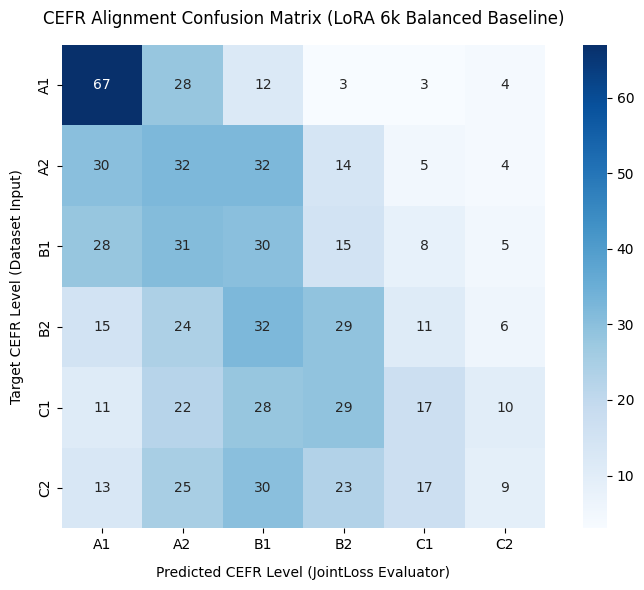

In [ ]:
# ==========================================
# 4. REPORT EXPORT GENERATION
# ==========================================
y_true = df_final['target_cefr']
y_pred = df_final['predicted_cefr']

strict_acc = df_final['strict_match'].mean() * 100
adj_acc = df_final['adjacent_match'].mean() * 100
mae = mean_absolute_error(y_true.map(label_map), y_pred.map(label_map))
avg_mdd = df_final['mdd'].mean()
avg_flesch = df_final['readability_flesch'].mean()
avg_drift = df_final['sentence_drift_max'].mean()

report_text = "="*60 + "\n"
report_text += " 📊 FINAL COMPILED MACRO-STATISTICS (LoRA BASELINE - 6k BALANCED)\n"
report_text += "="*60 + "\n"
report_text += f"Total Processed       : {len(df_final)}\n"
report_text += f"Strict Accuracy       : {strict_acc:.2f}%\n"
report_text += f"Adjacent Accuracy     : {adj_acc:.2f}%\n"
report_text += f"Mean Abs Error (MAE)  : {mae:.4f}\n"
report_text += f"Avg MDD Score         : {avg_mdd:.2f}\n"
report_text += f"Avg Reading Ease      : {avg_flesch:.2f}\n"
report_text += f"Avg Sentence Drift    : {avg_drift:.2f} levels\n"
report_text += "Avg Perplexity        : (Computed externally)\n"
report_text += "="*60 + "\n\n"

report_text += "📈 PERFORMANCE BREAKDOWN BY CEFR TARGET LEVEL:\n"
level_agg = df_final.groupby("target_cefr").agg(
    strict_accuracy=("strict_match", lambda x: np.mean(x) * 100),
    avg_mdd=("mdd", "mean"),
    avg_flesch=("readability_flesch", "mean"),
    avg_drift=("sentence_drift_max", "mean")
).round(2)
report_text += level_agg.to_string() + "\n\n"

report_text += "="*60 + "\n"
report_text += "📝 DETAILED CLASSIFICATION REPORT:\n"
cefr_labels = ["A1", "A2", "B1", "B2", "C1", "C2"]
report_text += classification_report(y_true, y_pred, labels=cefr_labels, zero_division=0)
report_text += "\n" + "="*60 + "\n"

# Output and write the TXT file locally
with open(OUTPUT_TXT_PATH, "w") as f:
    f.write(report_text)
print(report_text)

# Plot and export the Confusion Matrix file
cm = confusion_matrix(y_true, y_pred, labels=cefr_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cefr_labels, yticklabels=cefr_labels, cbar=True, square=True)
plt.title("CEFR Alignment Confusion Matrix (LoRA 6k Balanced Baseline)", fontsize=12, pad=15)
plt.xlabel("Predicted CEFR Level (JointLoss Evaluator)", fontsize=10, labelpad=10)
plt.ylabel("Target CEFR Level (Dataset Input)", fontsize=10, labelpad=10)
plt.tight_layout()
plt.savefig(OUTPUT_IMG_PATH, dpi=300)
print(f"🎨 Confusion Matrix plot successfully saved to: {OUTPUT_IMG_PATH}")